In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.filters.hp_filter import hpfilter
import os

### 13.2.1

In [2]:
def apply_hp_filter(data, country_name, lambda_param=100):
    """
    Apply natural log transformation and Hodrick-Prescott filter to GDP data.
    
    Parameters:
    -----------
    data : pandas.Series
        GDP data series with years as index
    country_name : str
        Name of the country for labeling
    lambda_param : int
        Smoothing parameter for HP filter
        
    Returns:
    --------
    tuple
        (cycle, trend) components from HP filter
    """
    # Apply natural log transformation
    log_data = np.log(data)
    
    # Apply HP filter to the log-transformed data
    cycle, trend = hpfilter(log_data, lamb=lambda_param)
    
    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
    
    # Plot original log data and trend
    ax1.plot(log_data.index, log_data, 'b-', label='Log GDP')
    ax1.plot(trend.index, trend, 'r-', label='Trend Component')
    ax1.set_title(f'{country_name} Log GDP and Trend Component')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Log GDP')
    ax1.legend()
    ax1.grid(True)
    
    # Plot cyclical component (output gap)
    ax2.plot(cycle.index, 100*cycle, 'g-') # multiply by 100 for percentage
    ax2.set_title(f'{country_name} Cyclical Component')
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Pct. Deviation from Trend')
    ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig(f'{country_name}_hp_filter_log.png')  # Save figure for reference
    plt.show()  # Show the plot directly
    
    return cycle, trend

In [3]:
# File path
file_path = 'Chap 13_Exc 2_GDP data_US_UK_SV_DK.xlsx'

# Read the Excel file
# Skip the header rows and use row 11 (index 10) as data start

# Read years from column A
years_df = pd.read_excel(file_path, sheet_name='Data', 
                        usecols='A', skiprows=10, header=None, 
                        names=['Year'], nrows=65)

# Read USA GDP from column B
usa_df = pd.read_excel(file_path, sheet_name='Data', 
                        usecols='B', skiprows=10, header=None, 
                        names=['USA'], nrows=65)

# Read UK GDP from column G
uk_df = pd.read_excel(file_path, sheet_name='Data', 
                        usecols='G', skiprows=10, header=None, 
                        names=['UK'], nrows=65)

# Read Sweden GDP from column L
sweden_df = pd.read_excel(file_path, sheet_name='Data', 
                            usecols='L', skiprows=10, header=None, 
                            names=['Sweden'], nrows=65)

# Read Denmark GDP from column Q
denmark_df = pd.read_excel(file_path, sheet_name='Data', 
                            usecols='Q', skiprows=10, header=None, 
                            names=['Denmark'], nrows=65)

# Combine all dataframes
gdp_df = pd.concat([years_df, usa_df, uk_df, sweden_df, denmark_df], axis=1)

# Set Year as index
gdp_df.set_index('Year', inplace=True)

c:\Users\Lindholm\anaconda3\lib\site-packages\openpyxl\worksheet\_read_only.py:79: UserWarning: Sparkline Group extension is not supported and will be removed
  for idx, row in parser.parse():
c:\Users\Lindholm\anaconda3\lib\site-packages\openpyxl\worksheet\_read_only.py:79: UserWarning: Sparkline Group extension is not supported and will be removed
  for idx, row in parser.parse():
c:\Users\Lindholm\anaconda3\lib\site-packages\openpyxl\worksheet\_read_only.py:79: UserWarning: Sparkline Group extension is not supported and will be removed
  for idx, row in parser.parse():
c:\Users\Lindholm\anaconda3\lib\site-packages\openpyxl\worksheet\_read_only.py:79: UserWarning: Sparkline Group extension is not supported and will be removed
  for idx, row in parser.parse():
c:\Users\Lindholm\anaconda3\lib\site-packages\openpyxl\worksheet\_read_only.py:79: UserWarning: Sparkline Group extension is not supported and will be removed
  for idx, row in parser.parse():


In [4]:
# Print data summary
print(f"GDP data from {gdp_df.index.min()} to {gdp_df.index.max()}")
print(f"Number of years: {len(gdp_df)}")
print("\nSummary statistics:")
print(gdp_df.describe())

GDP data from 1950 to 2014
Number of years: 65

Summary statistics:
                USA            UK         Sweden        Denmark
count  6.500000e+01  6.500000e+01      65.000000      65.000000
mean   8.148546e+06  1.276479e+06  204392.286719  123483.090745
std    4.483249e+06  6.254996e+05  105042.147125   62462.553420
min    2.274197e+06  4.737177e+05   65147.558594   38793.367188
25%    4.418792e+06  7.525140e+05  117725.085938   73211.179688
50%    6.901234e+06  1.126705e+06  171565.406250  109436.257812
75%    1.195692e+07  1.813215e+06  283372.843750  169237.750000
max    1.659810e+07  2.493278e+06  413410.468750  250851.734375



Processing USA GDP data...


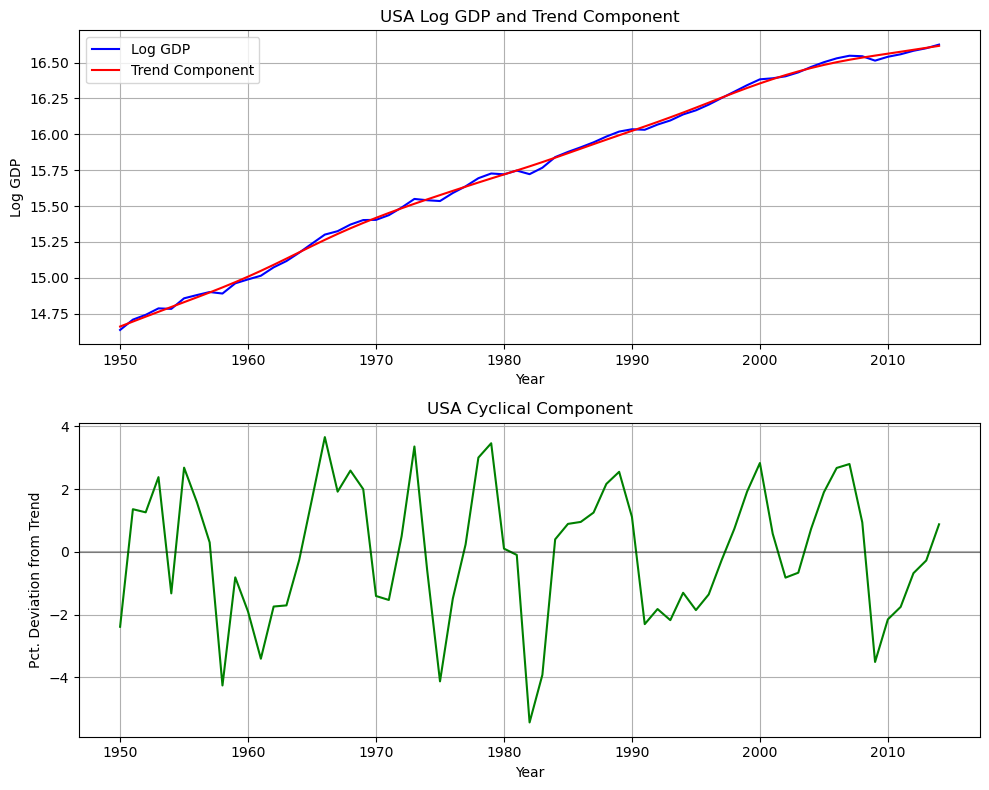


Processing UK GDP data...


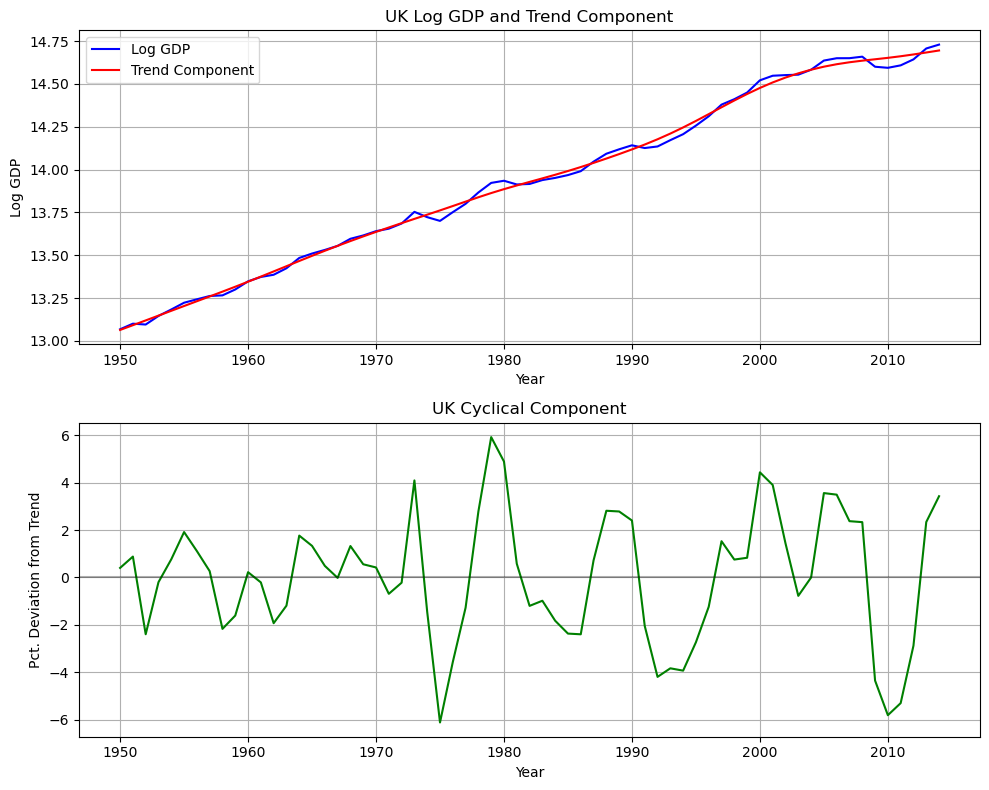


Processing Sweden GDP data...


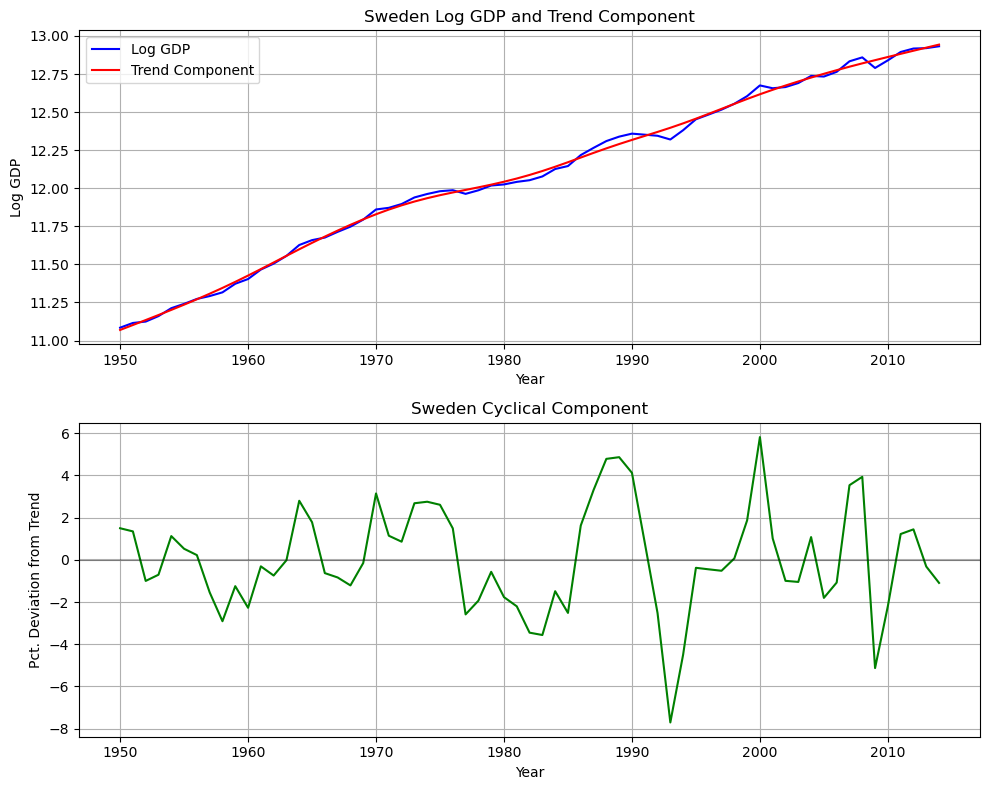


Processing Denmark GDP data...


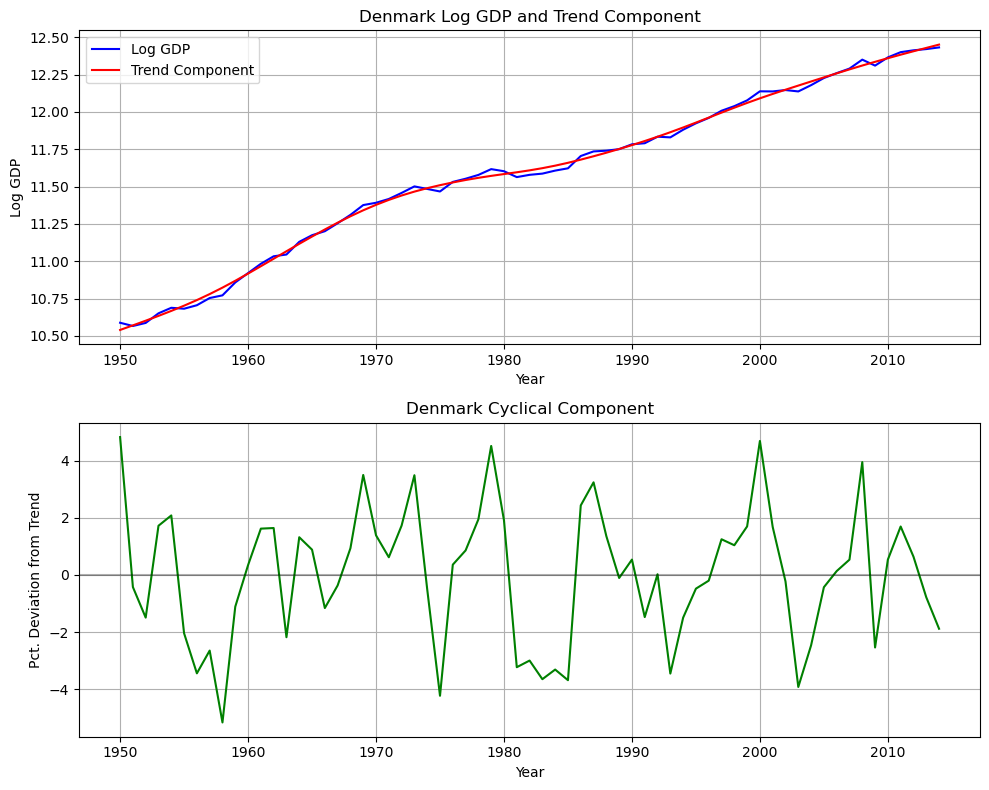

In [5]:
# Store all results in DataFrames for in-program inspection
# Dictionary to store all country DataFrames
country_results = {}

# Lambda parameter
lambda_param = 100

# Process each country
for country in ['USA', 'UK', 'Sweden', 'Denmark']:
    print(f"\nProcessing {country} GDP data...")
    
    # Apply HP filter with log transformation
    cycle, trend = apply_hp_filter(gdp_df[country], country, lambda_param)
    
    # Create a DataFrame with original log data, trend, and cycle components
    country_df = pd.DataFrame({
        'Original_GDP': gdp_df[country],
        'Log_GDP': np.log(gdp_df[country]),
        'Trend': trend,
        'Cycle': cycle
    })
    
    # Store in dictionary for later inspection
    country_results[country] = country_df

# Now all results are available in the country_results dictionary
# To inspect any country's results, use:
# country_results['USA'], country_results['UK'], etc.

In [6]:
# Example of how to access and display more results:
print("USA, last 5 years:")
print(country_results['USA'].tail())

USA, last 5 years:
      Original_GDP    Log_GDP      Trend     Cycle
Year                                              
2010    15250698.0  16.540136  16.561661 -0.021525
2011    15517930.0  16.557507  16.575052 -0.017545
2012    15899255.0  16.581783  16.588582 -0.006800
2013    16183547.0  16.599506  16.602261 -0.002755
2014    16598099.0  16.624799  16.616027  0.008772


### 13.2.2 Output gap 
The output gap = cycle = ln(GDP) - Trend is the deviation from trend. Multiply trend *100 to get pct deviation.

In [7]:
for country, df in country_results.items():
    df["Pct cycle"] = df["Cycle"] * 100

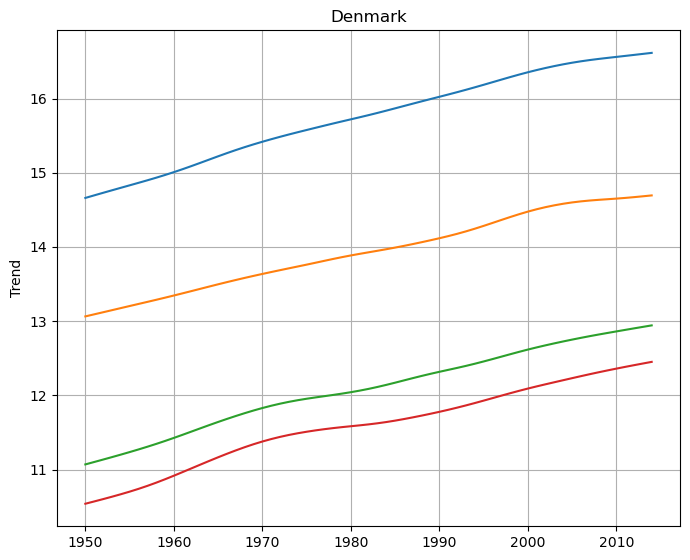

In [18]:
fig, ax = plt.subplots(squeeze=True, figsize=(7, 6))

for country, df in country_results.items():
    ax.plot(df.index, df["Trend"], label="f'{country} Trend")
    ax.set_title(country)
    ax.set_ylabel("Trend")
    ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


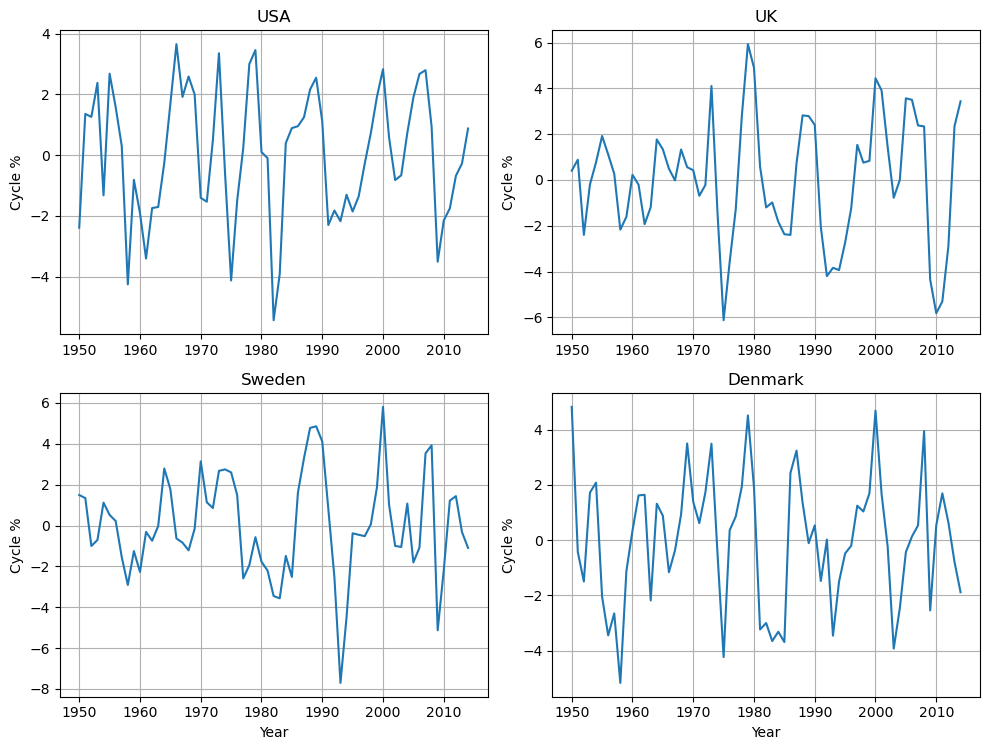

In [9]:
fig, axes = plt.subplots(2, 2, squeeze=True, figsize=(10, 8))

axes = axes.flatten() 

for idx, (country, df) in enumerate(country_results.items()):
    ax = axes[idx]
    ax.plot(df.index, df["Pct cycle"], label="f'{country} Cycle %")
    ax.set_title(country)
    ax.set_ylabel("Cycle %")
    ax.grid(True)

for ax in axes[2:]:
    ax.set_xlabel("Year")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


#### Plot cycles together.

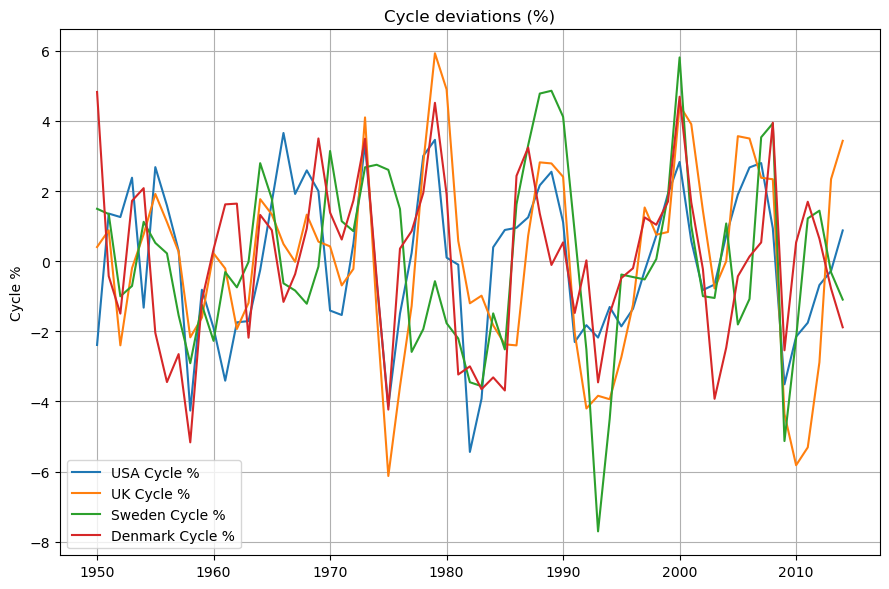

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))

for country, df in country_results.items():
    ax.plot(df.index, df["Pct cycle"], label=f"{country} Cycle %")
    ax.set_title("Cycle deviations (%)")
    ax.set_ylabel("Cycle %")
    ax.grid(True)

plt.legend()
plt.tight_layout()
plt.show()

### 13.2.3
Higher lambda values smooth the trend more, making it less sensitive to fluctuations in the data.

Pick lambda = 1000.

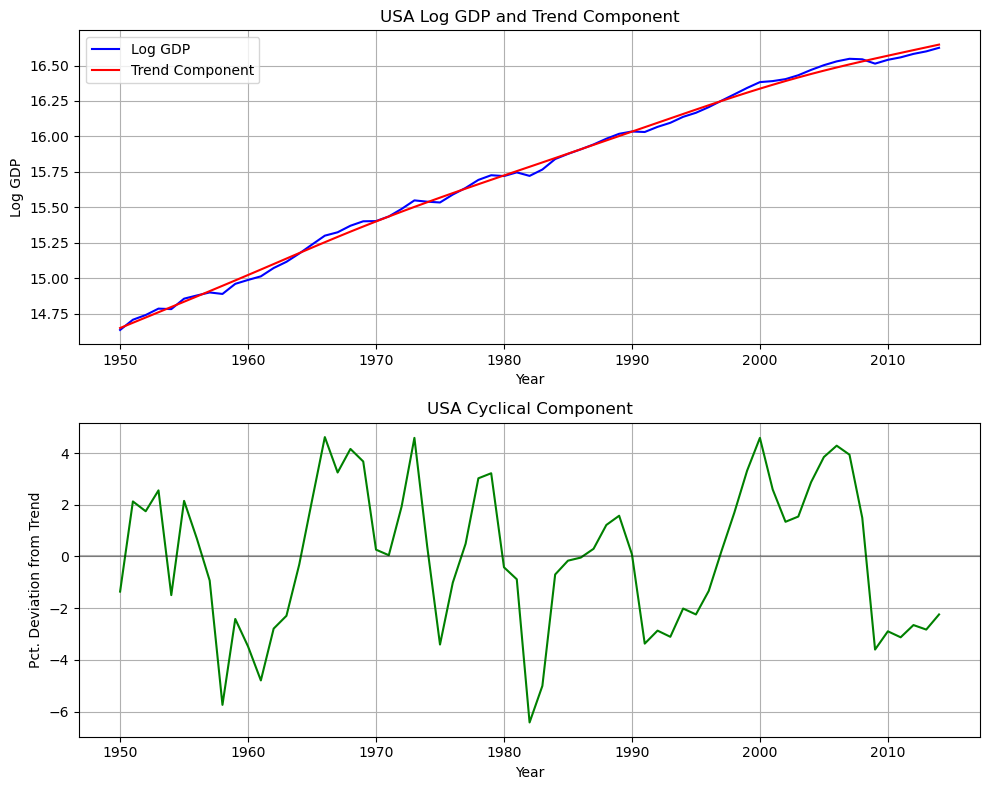

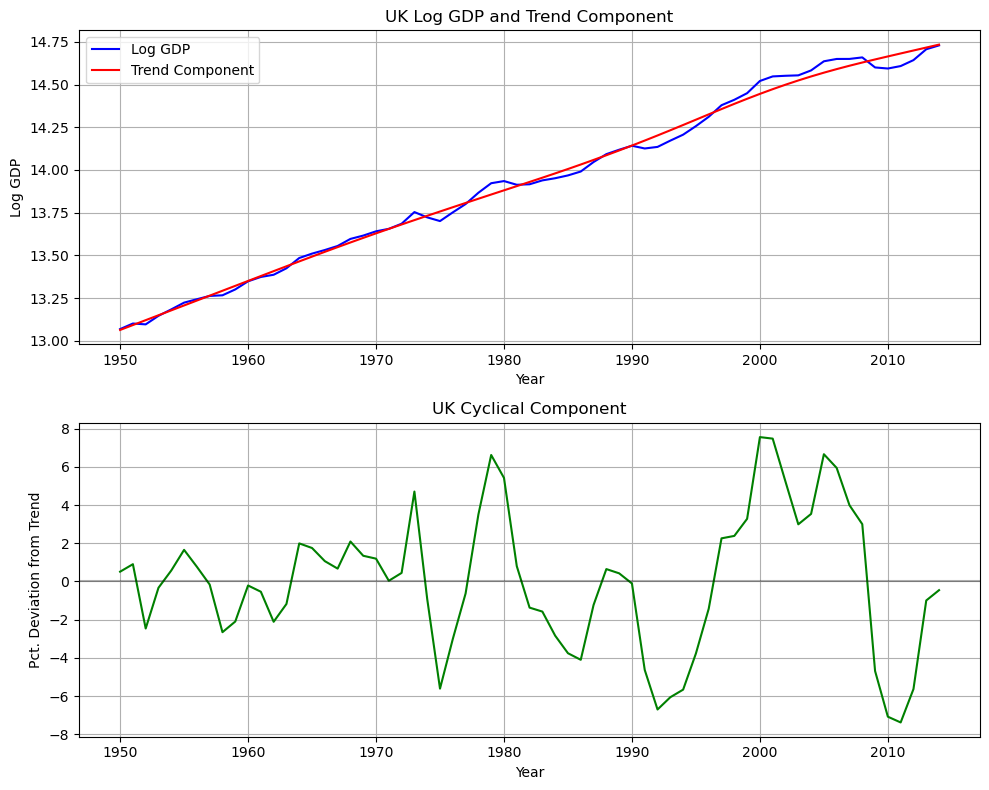

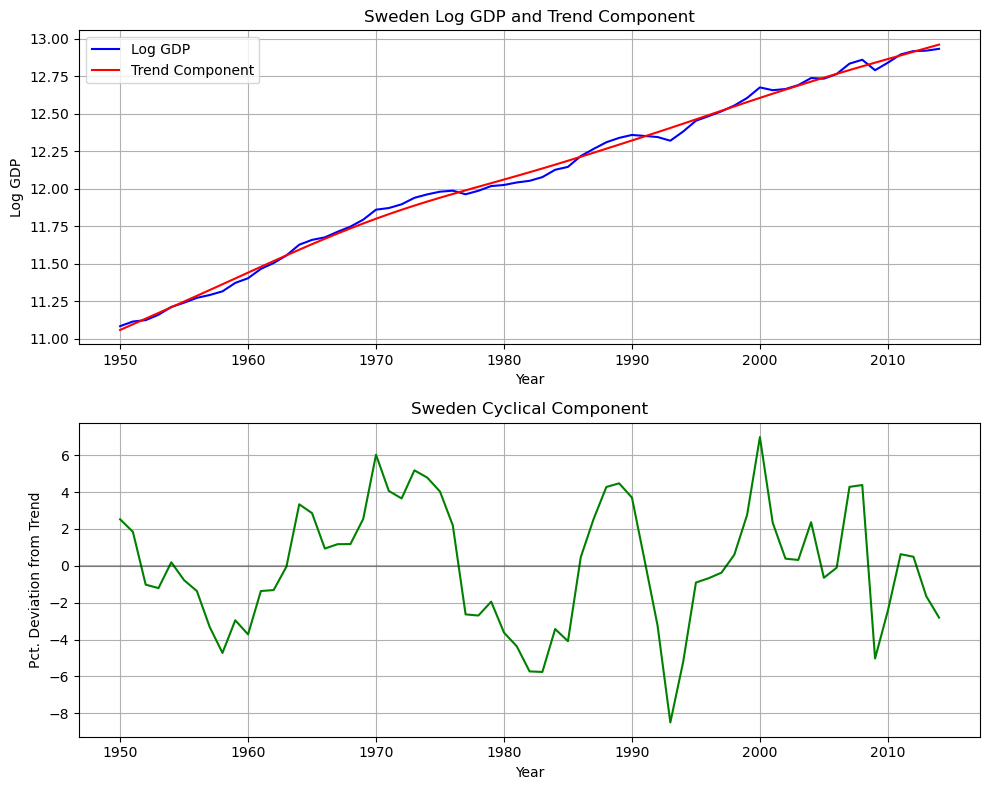

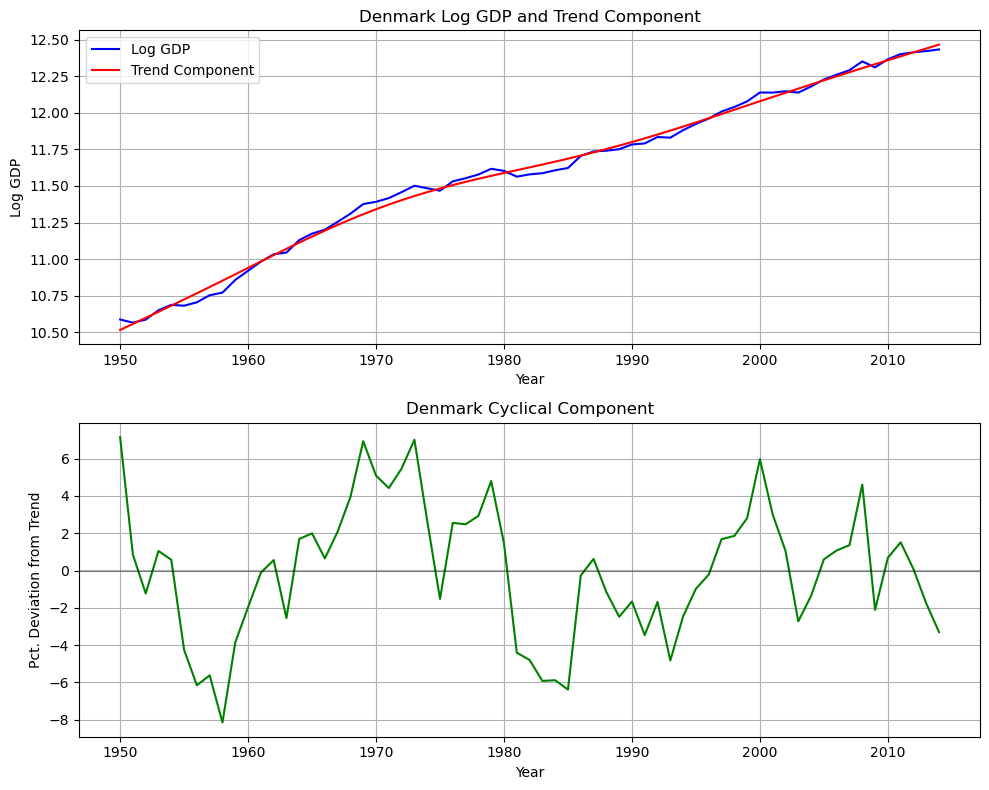

In [11]:
country_results_mid = {}
l = 1000 

for country in ["USA", "UK", "Sweden", "Denmark"]:
    cycle, trend = apply_hp_filter(gdp_df[country], country, lambda_param=l)

    country_df = pd.DataFrame({
        "Original_GDP": gdp_df[country],
        "Log_GDP": np.log(gdp_df[country]),
        "Trend": trend, 
        "Cycle": cycle,
        "Pct cycle": cycle * 100
})

    country_results_mid[country] = country_df

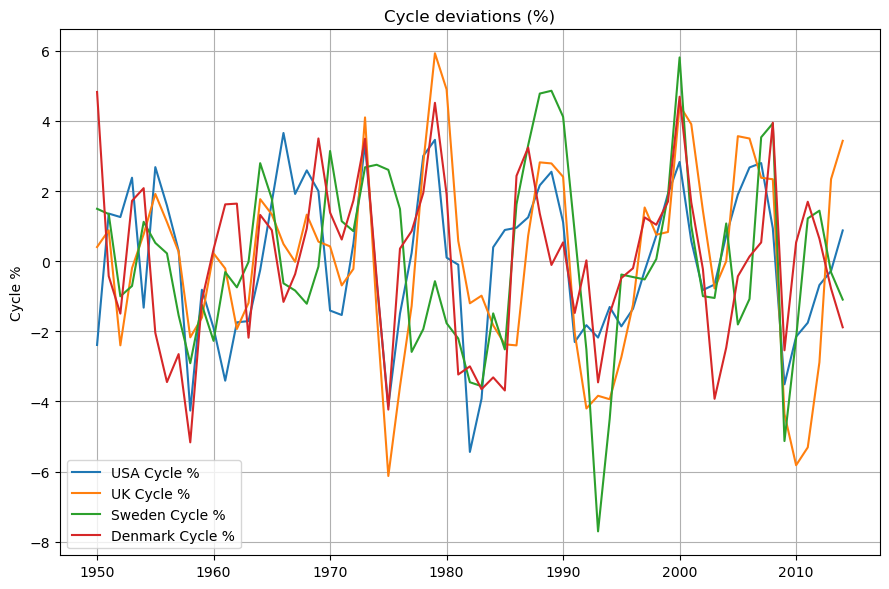

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))

for country, df in country_results.items():
    ax.plot(df.index, df["Pct cycle"], label=f"{country} Cycle %")
    ax.set_title("Cycle deviations (%)")
    ax.set_ylabel("Cycle %")
    ax.grid(True)

plt.legend()
plt.tight_layout()
plt.show()

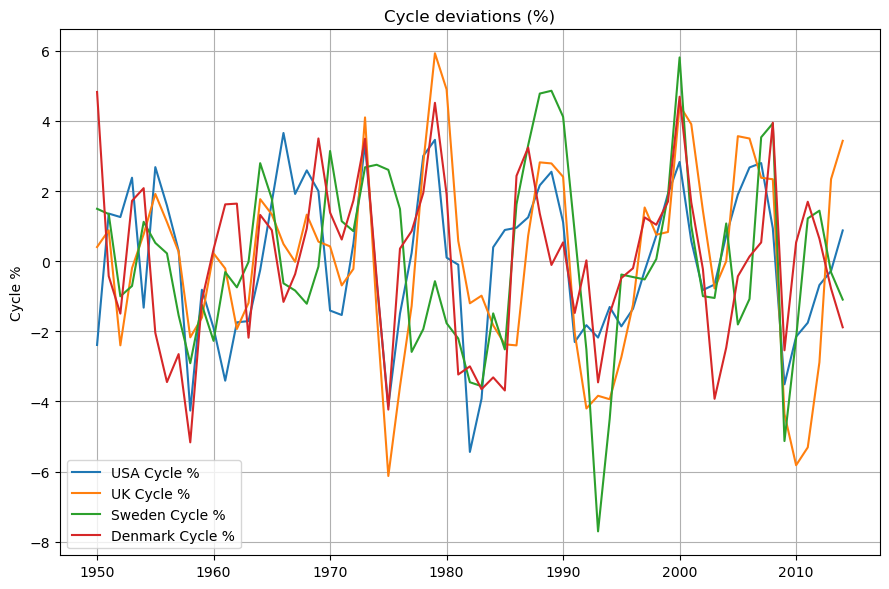

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))

for country, df in country_results.items():
    ax.plot(df.index, df["Pct cycle"], label=f"{country} Cycle %")
    ax.set_title("Cycle deviations (%)")
    ax.set_ylabel("Cycle %")
    ax.grid(True)

plt.legend()
plt.tight_layout()
plt.show()

In [14]:
country_results_mid["USA"]

,Original_GDP,Log_GDP,Trend,Cycle,Pct cycle
Year,,,,,
1950,2274197.25,14.637138,14.650737,-0.013599,-1.359916
1951,2443819.50,14.709073,14.687786,0.021287,2.128702
1952,2526412.25,14.742311,14.724821,0.017490,1.748976
1953,2642976.50,14.787416,14.761850,0.025566,2.556593
1954,2633803.00,14.783939,14.798899,-0.014960,-1.495964
...,...,...,...,...,...
2010,15250698.00,16.540136,16.569103,-0.028967,-2.896739
2011,15517930.00,16.557507,16.588793,-0.031287,-3.128651
2012,15899255.00,16.581783,16.608333,-0.026550,-2.654991


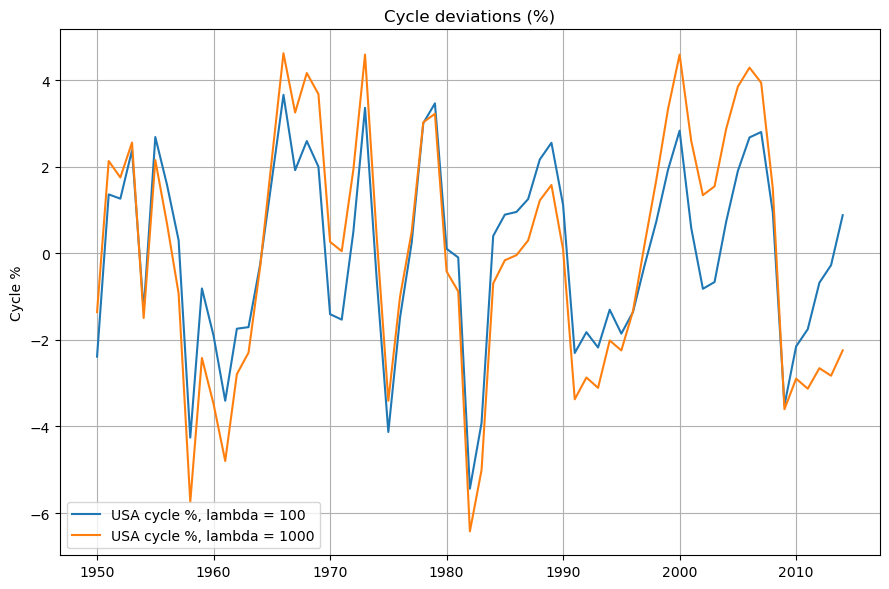

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(country_results["USA"].index, country_results["USA"]["Pct cycle"], label="USA cycle %, lambda = 100")
ax.plot(country_results_mid["USA"].index, country_results_mid["USA"]["Pct cycle"], label="USA cycle %, lambda = 1000")

ax.set_title("Cycle deviations (%)")
ax.set_ylabel("Cycle %")
ax.grid(True)

plt.legend()
plt.tight_layout()
plt.show()